# Breast Cancer Detection

A classification problem that uses a breast cancer dataset to predict whether cancer is present. This is a database native to Scikitlearn database.

Proposed solution uses a dense layer solution to solve the problem.

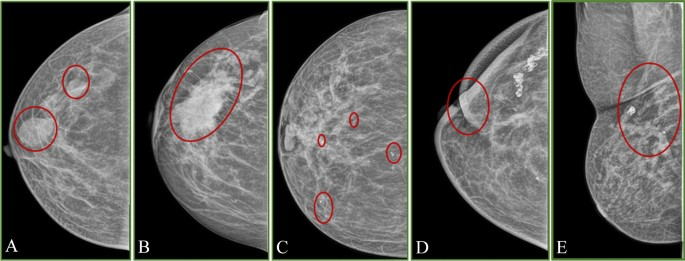

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.6709 - loss: 0.6315 - val_accuracy: 0.6842 - val_loss: 0.5490
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.7638 - loss: 0.5347 - val_accuracy: 0.8246 - val_loss: 0.4789
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8543 - loss: 0.4595 - val_accuracy: 0.8246 - val_loss: 0.4196
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9045 - loss: 0.4004 - val_accuracy: 0.8421 - val_loss: 0.3699
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9121 - loss: 0.3529 - val_accuracy: 0.8947 - val_loss: 0.3301
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9221 - loss: 0.3148 - val_accuracy: 0.8947 - val_loss: 0.2976
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9271 - loss: 0.2839 - val_accuracy: 0.9123 - val_loss: 0.2706
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9347 - loss: 0.2584 - val_accuracy: 0.

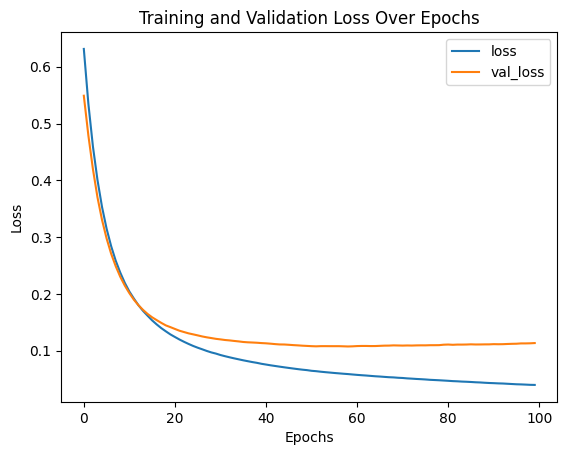

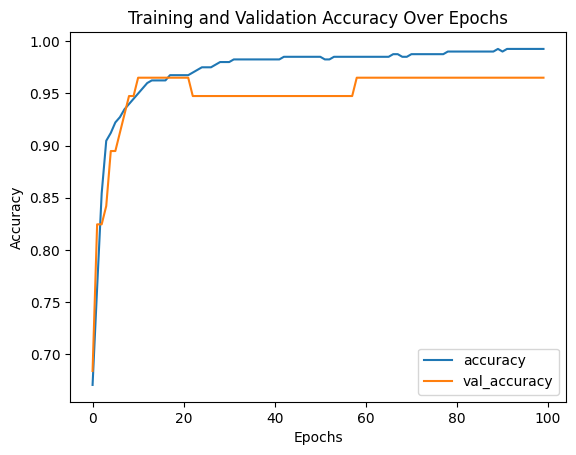

In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
#print(data.keys())
#print(data['DESCR'])

X_train, X_temp, y_train, y_temp = train_test_split(data.data, data.target, train_size = 0.7, random_state = 42) #split dataset into train & temp
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = (2/3), random_state = 42) #split temp into validation & test

N, D = X_train.shape
hidden_layer_size = 10

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape = (D,)),
    tf.keras.layers.Dense(hidden_layer_size, activation = 'relu'),
    tf.keras.layers.Dense(1, activation = 'sigmoid')
])

model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

r = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 100,
    batch_size = 32
)

test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test accuracy:', test_acc)
print('Test, loss', test_loss)

import matplotlib.pyplot as plt

# Plot loss
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot accuracy (if available in history)
# Check if accuracy is present in the history object
if 'accuracy' in r.history and 'val_accuracy' in r.history:
    plt.plot(r.history['accuracy'], label='accuracy')
    plt.plot(r.history['val_accuracy'], label='val_accuracy')
    plt.title('Training and Validation Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()
else:
    print("Accuracy metrics not found in model history.")